In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import re
from itertools import islice

In [2]:
# Load the dataset
df = pd.read_csv('results/questionnaires_answers_log.csv')

# drop by position (0-based)
df = df.drop(df.index[30])   # removes the 31st row
df = df.reset_index(drop=True)

df_experiment_details = pd.read_csv("results/experiment_runs_log_users_info_P7iwzVBKHYbSDrUWE.csv", header=0, usecols=range(13))

In [3]:
df_experiment_details

,date,time,Name,Age,Email,Gender,EducationalBackground,ProfessionalBackground,AIExperienceYears,ExplanationTypePreference,DetailsInExplanationPreference,RandomTempUID,IdNumber
0,21:13:48 16.09.25,1758057228,Ayatollah Yehia,28,ay8tb@virginia.edu,female,stem,stem,1-2,visual,detailed,UID_OK52uh59yc17Gg38pe,NaN
1,22:30:56 16.09.25,1758061856,Sherlock Chen,19,fvd6wy@virginia.edu,male,stem,stem,1-2,visual,detailed,UID_CQ55id42YA22Bu97pp,NaN
2,22:53:21 16.09.25,1758063201,Fangxu Yuan,25,phh3pb@virginia.edu,male,stem,stem,3-4,textual,detailed,UID_rG08eO82Em45tY61kJ,NaN
3,00:11:56 17.09.25,1758067916,Zackary Landsman,27,ztl4bm@virginia.edu,male,stem,stem,1-2,textual,detailed,UID_lZ99Om05Aw28dC75VO,NaN
4,00:22:50 17.09.25,1758068570,Ji Hyun Kim,29,mqa4qu@virginia.edu,female,stem,non-stem,1-2,visual,brief,UID_Op14Zg81Cu60eo02dG,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...
89,09:53:28 17.10.25,1760694808,Aya Shmoish,23,ashmoish@gmail.com,female,stem,stem,3-4,visual,brief,UID_bq81ma75cm55gt20dE,NaN
90,10:50:11 17.10.25,1760698211,Shira Schiber,22,Shiradsch@gmail.com,female,stem,stem,1-2,visual,brief,UID_Sw96eT15Yn09Zm37KQ,NaN
91,11:25:51 17.10.25,1760700351,Gabriel Soltz Grinspan,23,gabigrinspan@gmail.com,male,stem,stem,1-2,textual,brief,UID_hT41ae83oQ49hc87Qv,NaN
92,07:33:45 19.10.25,1760859225,Ittai Cohen,33,ittaicohen14.5@gmail.com,male,stem,non-stem,1-2,visual,brief,UID_aT05lo46IV73IQ84uz,NaN


## Check Accuracy in each group

In [4]:
def convert_2_int(num):
    if pd.isna(num) or num == '-':
        return None
    return int(num)

In [21]:
def analysis_test_results(users_logs, group_id):
    results = {}
    
    users_logs = users_logs[users_logs["ugroup"] == group_id]
    users = users_logs['tuid'].unique()
    
    for user in users:
        user_data = users_logs[users_logs["tuid"] == user]

        correct_count = 0
        correct_pred_count = 0 # for questions that pred == true
        incorrect_pred_count = 0 # for questions that pred != true
        
        questions = 0
        total_confidence = 0
        wrong_pred_questions = 0 # total pred!=true questions
        right_pred_questions = 0 # toal pred=true questions

        answer_pred_user = 0 # total questions where user_choice = pred
                
        for _, row in user_data.iterrows():
            blockId = row['selectedOptionName']
            true_choice = row['correctAnswerValue']
            pred_choice = row['aiSelectedOptionValue']
            user_choice = row['selectedOptionValue']

            # check if it is feedback or answer
            if "facesSlider" not in blockId: # ---> answer

                questions  += 1
                
                # check how many qeusiotns did the user answered correctly
                if user_choice == true_choice:
                    correct_count += 1
    
                    if true_choice == pred_choice:
                        correct_pred_count += 1
                    else:
                        incorrect_pred_count += 1

                # count how many correct and incorrect qeustions there are in the data
                if true_choice == pred_choice:
                    right_pred_questions += 1
    
                else:
                    wrong_pred_questions += 1

                # count how many questions the user and the pred where right
                if pred_choice == user_choice:
                    answer_pred_user += 1
                    
            elif "block_end" not in blockId: # ---> feedback per question
                total_confidence += convert_2_int(user_choice)

        if questions == 10: 
            results[user] = {
                "correct": correct_count,
                "questions": questions,
                "confidence": total_confidence,
                "correct_pred_count": correct_pred_count,
                "incorrect_pred_count": incorrect_pred_count,
                "right_pred_questions": right_pred_questions,
                "wrong_pred_questions": wrong_pred_questions,
                "answer_pred_user": answer_pred_user
                
            }
        # else:
        #     print(group_id, user, {
        #         "correct": correct_count,
        #         "questions": questions,
        #         "confidence": total_confidence,
        #         "correct_pred_count": correct_pred_count,
        #         "incorrect_pred_count": incorrect_pred_count,
        #         "right_pred_questions": right_pred_questions,
        #         "wrong_pred_questions": wrong_pred_questions,
        #     }, "------")
        
    return results

In [27]:
group_a_data = analysis_test_results(df, "A")
group_b_data = analysis_test_results(df, "B")
group_c_data = analysis_test_results(df, "C")
group_d_data = analysis_test_results(df, "D")

all_users = group_a_data | group_b_data | group_c_data | group_d_data

group_a_data = dict(islice(group_a_data.items(), 20))
group_b_data = dict(islice(group_b_data.items(), 20))
group_c_data = dict(islice(group_c_data.items(), 20))
group_d_data = dict(islice(group_d_data.items(), 20))

all_groups = group_a_data | group_b_data | group_c_data | group_d_data

## Payment

In [13]:
users = {
    "Guy Gedalya": "UID_cA26mv07oN97bX58tH",
    "Matan Dabush": "UID_qD05Ru17Mu33KG63hn",
    "Jonathan Freund": "UID_ug24hL65Ow73PW18xI",
    "Yinon Yfrach": "UID_lA21Of82Ct84Zi86eT",
    "yinon ernest": "UID_Xs65XK08QB39hn10hQ",
    "Matania Segalovitch":"UID_oH95MC45ee41BH64Yi",
    "Omri  Yanku": "UID_nz39Im56xb53fr60cv",
    "Hila Lucky": "UID_OD86mb97wy67Eg22fc",
    "Thomas Kowalski": "UID_QQ92Ft68nh86oU22jZ",
    "Yuval Shapira": "UID_dT19xs25DD43WR91Ct",
    "Gabriele Guetta": "UID_zP28Yo37OF81hO08ky",
    "Ori Bahat Petel": "UID_Lf26YD71zv67SZ76WP",
    "Yedidya Darshan": "UID_Tx99hn42YE28tK90tZ",
    "Ben Eli":"UID_fx66MG91rc91ME96OY",
    "Aya Shmoish": "UID_bq81ma75cm55gt20dE",
    "Shira Schiber": "UID_Sw96eT15Yn09Zm37KQ",
    "Ittai Cohen": "UID_aT05lo46IV73IQ84uz",
    "Ido Tziony": "UID_RV63uP66pH66Rr20nD"
}

for user in users:
    user_id = users[user]
    if user_id in all_groups.keys():
        print(user, all_groups[user_id], "\n")
    else: 
        print(user, "\n")

Guy Gedalya {'correct': 6, 'questions': 10, 'confidence': 45, 'correct_pred_count': 5, 'incorrect_pred_count': 1, 'right_pred_questions': 6, 'wrong_pred_questions': 4, 'answer_pred_user': 8} 

Matan Dabush {'correct': 7, 'questions': 10, 'confidence': 40, 'correct_pred_count': 6, 'incorrect_pred_count': 1, 'right_pred_questions': 6, 'wrong_pred_questions': 4, 'answer_pred_user': 8} 

Jonathan Freund {'correct': 6, 'questions': 10, 'confidence': 40, 'correct_pred_count': 4, 'incorrect_pred_count': 2, 'right_pred_questions': 6, 'wrong_pred_questions': 4, 'answer_pred_user': 6} 

Yinon Yfrach {'correct': 4, 'questions': 10, 'confidence': 42, 'correct_pred_count': 4, 'incorrect_pred_count': 0, 'right_pred_questions': 6, 'wrong_pred_questions': 4, 'answer_pred_user': 6} 

yinon ernest 

Matania Segalovitch {'correct': 7, 'questions': 10, 'confidence': 30, 'correct_pred_count': 5, 'incorrect_pred_count': 2, 'right_pred_questions': 6, 'wrong_pred_questions': 4, 'answer_pred_user': 7} 

Omri  

## Lottery

In [33]:
lottery_users = [
    'UID_OK52uh59yc17Gg38pe',
    'UID_CQ55id42YA22Bu97pp',
    'UID_rG08eO82Em45tY61kJ',
    'UID_lZ99Om05Aw28dC75VO',
    'UID_Op14Zg81Cu60eo02dG',
    'UID_pT31JK49dd29dQ77Fc',
    'UID_LC34wX85kB05oR78lK',
    'UID_pC09RY22rU75HT50pE',
    'UID_sl03tl00xA53dG47Ad',
    'UID_Mr19Ag83hs40Ww88Ss',
    'UID_dq11Qq12gf39rm62MI',
    'UID_tS40Mq77cQ54TK32dV',
    'UID_qG24UT89rb01jB93TU',
    'UID_pP56OU88PB03mL78ZL',
    'UID_we29LM61Gb71sd27Bc',
    'UID_iJ74Cu20Cx77sd78bo',
    'UID_GQ99LE04Yj17hj44dK',
    'UID_cA26mv07oN97bX58tH',
    'UID_qD05Ru17Mu33KG63hn',
    'UID_ug24hL65Ow73PW18xI',
    'UID_lA21Of82Ct84Zi86eT',
    'UID_oH95MC45ee41BH64Yi',
    'UID_nz39Im56xb53fr60cv',
    'UID_OD86mb97wy67Eg22fc',
    'UID_QQ92Ft68nh86oU22jZ',
    'UID_dT19xs25DD43WR91Ct',
    'UID_Lf26YD71zv67SZ76WP',
    'UID_Tx99hn42YE28tK90tZ',
    'UID_fx66MG91rc91ME96OY',
    'UID_bq81ma75cm55gt20dE',
    'UID_Sw96eT15Yn09Zm37KQ',
    'UID_hT41ae83oQ49hc87Qv',
    'UID_aT05lo46IV73IQ84uz',
    'UID_RV63uP66pH66Rr20nD',
]

In [34]:
for user in lottery_users:
    if user not in all_users:
        print(user)

In [35]:
# all_groups
correct_more_7 = []

for user in lottery_users:
    if all_users[user]['correct'] >= 7:
        correct_more_7.append(user)

In [36]:
import random

## Lottery # 1 - 50$
print(random.choice(lottery_users))

UID_pC09RY22rU75HT50pE


In [32]:
## Lottery # 2 - 25$
print(random.choice(correct_more_7))

UID_Sw96eT15Yn09Zm37KQ


### Print the table 

In [12]:
def get_success_per_group(group_data):
    correct = 0
    total_questions = 0

    correct_pred_count = 0
    incorrect_pred_count = 0

    right_pred_questions = 0
    wrong_pred_qeustions = 0

    answer_pred_user = 0
    
    for user in group_data:
        correct += group_data[user]['correct']
        total_questions += group_data[user]['questions']
        # total_questions += group_data[user]['right_pred_questions']+group_data[user]['wrong_pred_questions']

        if 'correct_pred_count' and 'incorrect_pred_count' in group_data[user]:
            correct_pred_count += group_data[user]['correct_pred_count']
            incorrect_pred_count += group_data[user]['incorrect_pred_count']

        if 'right_pred_questions' and 'wrong_pred_questions' in group_data[user]:
            right_pred_questions += group_data[user]['right_pred_questions']
            wrong_pred_qeustions += group_data[user]['wrong_pred_questions']

        if 'answer_pred_user' in group_data[user]:
            answer_pred_user += group_data[user]['answer_pred_user']

    # accuracy = f"{(correct / total_questions) * 100:.1f}"
    return correct, total_questions, len(group_data), correct_pred_count, incorrect_pred_count, right_pred_questions, wrong_pred_qeustions, answer_pred_user

In [134]:
groups = {
    'A - prediction only': group_a_data,
    'B - prediction & LLM ': group_b_data,
    'C - prediction & expets explanation': group_c_data,
    'D - prediction & confidence': group_d_data, 
}

In [135]:
print('------------ Accuracy Table: User Choice vs. True Choice -------------')
rows = []
for group_id, data in groups.items():

    correct, total, participants, correct_pred, incorrect_pred, right_pred_questions, wrong_pred_quesionts, answer_pred_user = get_success_per_group(data)
    accuracy = round((correct / total) * 100, 1)

    row = {
        'Group': group_id,
        'Correct answers': correct,
        'Total questions': total,
        'Accuracy': f"{accuracy}%",
        'Participants': participants, 
        'Correctly Predicted Answers': f"{correct_pred}/{right_pred_questions} ~ {(correct_pred/right_pred_questions)*100:.1f}%",
        'Incorrectly Predicted Answers': f"{incorrect_pred}/{wrong_pred_quesionts} ~ {(incorrect_pred/wrong_pred_quesionts)*100:.1f}%",
    }
    rows.append(row)

df_result = pd.DataFrame(rows)
df_result

------------ Accuracy Table: User Choice vs. True Choice -------------


,Group,Correct answers,Total questions,Accuracy,Participants,Correctly Predicted Answers,Incorrectly Predicted Answers
0,A - prediction only,97,200,48.5%,20,75/120 ~ 62.5%,22/80 ~ 27.5%
1,B - prediction & LLM,145,200,72.5%,20,107/120 ~ 89.2%,38/80 ~ 47.5%
2,C - prediction & expets explanation,111,200,55.5%,20,82/120 ~ 68.3%,29/80 ~ 36.2%
3,D - prediction & confidence,94,200,47.0%,20,66/120 ~ 55.0%,28/80 ~ 35.0%


In [136]:
print('------------ Accuracy Table: User Choice vs. Predicted Choice -------------')
rows = []
for group_id, data in groups.items():

    correct, total, participants, correct_pred, incorrect_pred, right_pred_questions, wrong_pred_quesionts, answer_pred_user = get_success_per_group(data)
    accuracy_true = round((correct / total) * 100, 1)
    accuracy_pred = round((answer_pred_user / total) * 100, 1)

    row = {
        'Group': group_id,
        '# Answers (user choice = true)': correct,
        '# Answers (user choice = pred)': answer_pred_user,
        'Total questions': total,
        'Accuracy (user choice = true)': f"{accuracy_true}%",
        'Accuracy (user choice = pred)': f"{accuracy_pred}%",
        'Participants': participants, 
    }
    rows.append(row)

df_result = pd.DataFrame(rows)
df_result

------------ Accuracy Table: User Choice vs. Predicted Choice -------------


,Group,# Answers (user choice = true),# Answers (user choice = pred),Total questions,Accuracy (user choice = true),Accuracy (user choice = pred),Participants
0,A - prediction only,97,120,200,48.5%,60.0%,20
1,B - prediction & LLM,145,148,200,72.5%,74.0%,20
2,C - prediction & expets explanation,111,124,200,55.5%,62.0%,20
3,D - prediction & confidence,94,105,200,47.0%,52.5%,20


## Check what is the confidence rate

In [38]:
def calculate_mean_confidence(group_data, group_name=""):
    total_confidence = 0
    total_questions = 0

    for i, user in enumerate(group_data, start=1):
        user_conf = group_data[user]['confidence']
        user_q = group_data[user]['questions']

        total_confidence += user_conf
        total_questions += user_q

        user_mean = user_conf / user_q if user_q else 0
        # print(f"User #{i}: mean confidence = {user_mean:.1f}")

    overall_mean = total_confidence / total_questions if total_questions else 0
    print(f"Group {group_name} overall mean confidence: {overall_mean:.3f}")
    return overall_mean

In [39]:
mean_confidene_group_a = calculate_mean_confidence(group_a_data, "A")
mean_confidene_group_b = calculate_mean_confidence(group_b_data, "B")
mean_confidene_group_c = calculate_mean_confidence(group_c_data, "C")
mean_confidene_group_d = calculate_mean_confidence(group_d_data, "D")

Group A overall mean confidence: 4.365
Group B overall mean confidence: 4.455
Group C overall mean confidence: 4.415
Group D overall mean confidence: 4.245


## Check the post hoc questions results

In [61]:
def mean_last_3_answers_first20(users_logs: pd.DataFrame, group_id: str):
    explanation_map = {
        "A": "ONLY_PREDICTION",
        "B": "LLM_EXPLANATION",
        "C": "OTHER_EXPLANATION",
        "D": "PREDICTION_WITH_CONFIDENCE",
    }
    explanation = explanation_map[group_id]

    g = users_logs[users_logs["ugroup"] == group_id].copy()

    for col in ["timestamp", "ts", "createdAt", "time"]:
        if col in g.columns:
            g = g.sort_values(col)
            break 

    first20 = (
        g.loc[g["tuid"].notna(), "tuid"]
        .drop_duplicates()
        .head(20)
        .tolist()
    )

    def q_mean(k: int):
        rows = g[
            (g["selectedOptionName"] ==
             f"facesSlider_block_end_questionnaire_explanation_{explanation}_question_{k}")
            & (g["tuid"].isin(first20))
        ].copy()

        if not rows.empty:
            rows = rows.drop_duplicates(subset=["tuid"], keep="last")

        rows["selectedOptionValue"] = pd.to_numeric(rows["selectedOptionValue"], errors="coerce")

        return rows["selectedOptionValue"].mean()

    means = np.array([q_mean(1), q_mean(2), q_mean(3)], dtype=float)
    participants = len(first20)  # אמור להיות 20, אבל אם יש פחות—זה מה שיש בפועל
    return means, participants

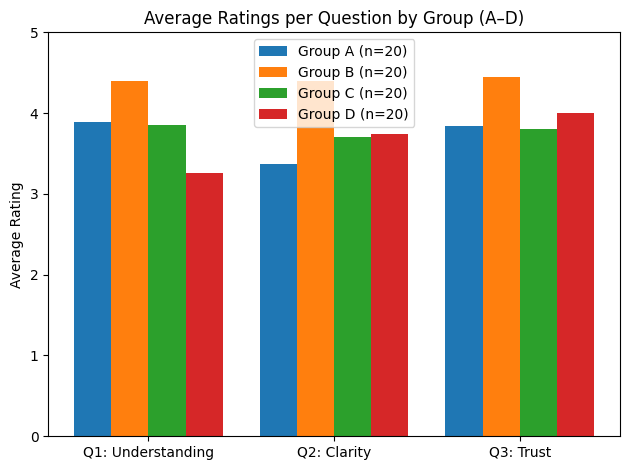

In [62]:
A_means, A_participants = mean_last_3_answers_first20(df, "A")
B_means, B_participants = mean_last_3_answers_first20(df, "B")
C_means, C_participants = mean_last_3_answers_first20(df, "C")
D_means, D_participants = mean_last_3_answers_first20(df, "D")

questions = ["Q1: Understanding", "Q2: Clarity", "Q3: Trust"]
x = list(range(len(questions)))
width = 0.2

fig, ax = plt.subplots()

ax.bar([i - 1.5*width for i in x], A_means, width, label=f"Group A (n={A_participants})")
ax.bar([i - 0.5*width for i in x], B_means, width, label=f"Group B (n={B_participants})")
ax.bar([i + 0.5*width for i in x], C_means, width, label=f"Group C (n={C_participants})")
ax.bar([i + 1.5*width for i in x], D_means, width, label=f"Group D (n={D_participants})")

ax.set_ylabel("Average Rating")
ax.set_title("Average Ratings per Question by Group (A–D)")
ax.set_xticks(x)
ax.set_xticklabels(questions)
ax.set_ylim(0, 5)
ax.legend()
plt.tight_layout()
plt.show()

# Check results based on personal details

In [108]:
def get_users_details(df):
    users = {}
    
    for _, row in df.iterrows():
        
        random_id = row['RandomTempUID']
        
        users[random_id] = {
            "name": row['time'],
            "age": row['Age'],
            "gender": row['Gender'],
            "ai_experince": row['AIExperienceYears'],
            "explanation_type_preffered": row['ExplanationTypePreference'],
            "details_explanation_preffered": row['DetailsInExplanationPreference'],
        }

    return users

In [109]:
users_details = get_users_details(df_experiment_details)

users_results = group_a_data | group_b_data | group_c_data | group_d_data

In [110]:
df_experiment_details.head()

,date,time,Name,Age,Email,Gender,EducationalBackground,ProfessionalBackground,AIExperienceYears,ExplanationTypePreference,DetailsInExplanationPreference,RandomTempUID,IdNumber
0,21:13:48 16.09.25,1758057228,Ayatollah Yehia,28,ay8tb@virginia.edu,female,stem,stem,1-2,visual,detailed,UID_OK52uh59yc17Gg38pe,NaN
1,22:30:56 16.09.25,1758061856,Sherlock Chen,19,fvd6wy@virginia.edu,male,stem,stem,1-2,visual,detailed,UID_CQ55id42YA22Bu97pp,NaN
2,22:53:21 16.09.25,1758063201,Fangxu Yuan,25,phh3pb@virginia.edu,male,stem,stem,3-4,textual,detailed,UID_rG08eO82Em45tY61kJ,NaN
3,00:11:56 17.09.25,1758067916,Zackary Landsman,27,ztl4bm@virginia.edu,male,stem,stem,1-2,textual,detailed,UID_lZ99Om05Aw28dC75VO,NaN
4,00:22:50 17.09.25,1758068570,Ji Hyun Kim,29,mqa4qu@virginia.edu,female,stem,non-stem,1-2,visual,brief,UID_Op14Zg81Cu60eo02dG,NaN


In [111]:
def get_table_results(groups):
    rows = []
    for group_id, data in groups.items():
    
        correct, total, participants, correct_pred, incorrect_pred, right_pred_questions, wrong_pred_quesionts, answer_pred_user = get_success_per_group(data)
    
        row = {
            'Group': group_id,
            'Correct answers': correct,
            'Total questions': total,
            'Accuracy': f"{round((correct / total) * 100, 1)}%" if total!=0 else '-',
            'Participants': participants, 
        }
        rows.append(row)
    
    df_result = pd.DataFrame(rows)
    return df_result

## Check what was the accuracy in the gender groups

In [112]:
def divide_groups_by_gender(users_results, users_details):
    women = {
        user: users_results[user] | users_details[user]
        for user in users_results
        if users_details[user].get('gender') == 'female'
    }
    men = {
        user: users_results[user] | users_details[user]
        for user in users_results
        if users_details[user].get('gender') == 'male'
    }
    return women, men

In [113]:
women, men = divide_groups_by_gender(users_results, users_details)

women_group_a, men_group_a = divide_groups_by_gender(group_a_data, users_details)
women_group_b, men_group_b = divide_groups_by_gender(group_b_data, users_details)
women_group_c, men_group_c = divide_groups_by_gender(group_c_data, users_details)
women_group_d, men_group_d = divide_groups_by_gender(group_d_data, users_details)

In [114]:
gender_table = get_table_results(groups = {
    'Female (all participants)': women,
    'Male (all participants)': men,
    'Female (Group A)': women_group_a, 
    'Female (Group B)': women_group_b, 
    'Female (Group C)': women_group_c, 
    'Female (Group D)': women_group_d, 
    'Male (Group A)': men_group_a,   
    'Male (Group B)': men_group_b,
    'Male (Group C)': men_group_c,
    'Male (Group D)': men_group_d
})
gender_table

,Group,Correct answers,Total questions,Accuracy,Participants
0,Female (all participants),144,260,55.4%,26
1,Male (all participants),303,540,56.1%,54
2,Female (Group A),36,80,45.0%,8
3,Female (Group B),51,70,72.9%,7
4,Female (Group C),32,60,53.3%,6
5,Female (Group D),25,50,50.0%,5
6,Male (Group A),61,120,50.8%,12
7,Male (Group B),94,130,72.3%,13
8,Male (Group C),79,140,56.4%,14
9,Male (Group D),69,150,46.0%,15


## Check what was the accuracy in the ai experience groups

In [115]:
def divide_groups_by_ai_experience(users_results, users_details):
    ai_0_1 = {
        user: users_results[user] | users_details[user]
        for user in users_results
        if users_details[user].get('ai_experince') == '0-1'
    }
    ai_1_2 = {
        user: users_results[user] | users_details[user]
        for user in users_results
        if users_details[user].get('ai_experince') == '1-2'
    }
    ai_3_4 = {
        user: users_results[user] | users_details[user]
        for user in users_results
        if users_details[user].get('ai_experince') == '3-4'
    }
    ai_5 = {
        user: users_results[user] | users_details[user]
        for user in users_results
        if users_details[user].get('ai_experince') == '5'
    }
    return ai_0_1, ai_1_2, ai_3_4, ai_5

In [116]:
ai_0_1, ai_1_2, ai_3_4, ai_5 = divide_groups_by_ai_experience(users_results, users_details)

ai_0_1_A, ai_1_2_A, ai_3_4_A, ai_5_A = divide_groups_by_ai_experience(group_a_data, users_details)
ai_0_1_B, ai_1_2_B, ai_3_4_B, ai_5_B = divide_groups_by_ai_experience(group_b_data, users_details)
ai_0_1_C, ai_1_2_C, ai_3_4_C, ai_5_C = divide_groups_by_ai_experience(group_c_data, users_details)
ai_0_1_D, ai_1_2_D, ai_3_4_D, ai_5_D = divide_groups_by_ai_experience(group_d_data, users_details)

In [117]:
ai_experience_table = get_table_results(groups = {
    'AI Experience: 0-1 Years (all participants)': ai_0_1,
    'AI Experience: 1-2 Years (all participants)': ai_1_2,
    'AI Experience: 3–4 Years (all participants)': ai_3_4,
    'AI Experience: 5+ Years (all participants)': ai_5,
    
    'AI Experience: 0-1 Years (group A)': ai_0_1_A,
    'AI Experience: 0-1 Years (group B)': ai_0_1_B,
    'AI Experience: 0-1 Years (group C)': ai_0_1_C,
    'AI Experience: 0-1 Years (group D)': ai_0_1_D,
    
    'AI Experience: 1-2 Years (group A)': ai_1_2_A,
    'AI Experience: 1-2 Years (group B)': ai_1_2_B,
    'AI Experience: 1-2 Years (group C)': ai_1_2_C,
    'AI Experience: 1-2 Years (group D)': ai_1_2_D,
    
    'AI Experience: 3–4 Years (group A)': ai_3_4_A,
    'AI Experience: 3–4 Years (group B)': ai_3_4_B,
    'AI Experience: 3–4 Years (group C)': ai_3_4_C,
    'AI Experience: 3–4 Years (group D)': ai_3_4_D,
    
    'AI Experience: 5+ Years (group A)': ai_5_A,
    'AI Experience: 5+ Years (group B)': ai_5_B,
    'AI Experience: 5+ Years (group C)': ai_5_C,
    'AI Experience: 5+ Years (group D)': ai_5_D,
})
ai_experience_table

,Group,Correct answers,Total questions,Accuracy,Participants
0,AI Experience: 0-1 Years (all participants),73,130,56.2%,13
1,AI Experience: 1-2 Years (all participants),159,280,56.8%,28
2,AI Experience: 3–4 Years (all participants),174,310,56.1%,31
3,AI Experience: 5+ Years (all participants),0,0,-,0
4,AI Experience: 0-1 Years (group A),21,50,42.0%,5
5,AI Experience: 0-1 Years (group B),18,20,90.0%,2
6,AI Experience: 0-1 Years (group C),19,40,47.5%,4
7,AI Experience: 0-1 Years (group D),15,20,75.0%,2
8,AI Experience: 1-2 Years (group A),40,70,57.1%,7
9,AI Experience: 1-2 Years (group B),56,80,70.0%,8


### Check what was the accuracy in the ExplanationTypePreference groups

In [118]:
def divide_groups_by_explanation_type(users_results, users_details):
    visual = {
        user: users_results[user] | users_details[user]
        for user in users_results
        if users_details[user].get('explanation_type_preffered') == 'visual'
    }
    textual = {
        user: users_results[user] | users_details[user]
        for user in users_results
        if users_details[user].get('explanation_type_preffered') == 'textual'
    }
    return visual, textual

In [119]:
visual, textual = divide_groups_by_explanation_type(users_results, users_details)

visual_A, textual_A = divide_groups_by_explanation_type(group_a_data, users_details)
visual_B, textual_B = divide_groups_by_explanation_type(group_b_data, users_details)
visual_C, textual_C = divide_groups_by_explanation_type(group_c_data, users_details)
visual_D, textual_D = divide_groups_by_explanation_type(group_d_data, users_details)

In [120]:
explnation_type_table = get_table_results(groups = {
    'Visual explanation preffered (all participants)': visual,
    'Textual explanation preffered (all participants)': textual,

    'Visual explanation preffered (group A)': visual_A,
    'Visual explanation preffered (group B)': visual_B,
    'Visual explanation preffered (group C)': visual_C,
    'Visual explanation preffered (group D)': visual_D,
    
    'Textual explanation preffered (group A)': textual_A,
    'Textual explanation preffered (group B)': textual_B,
    'Textual explanation preffered (group C)': textual_C,
    'Textual explanation preffered (group D)': textual_D,
})
explnation_type_table

,Group,Correct answers,Total questions,Accuracy,Participants
0,Visual explanation preffered (all participants),172,300,57.3%,30
1,Textual explanation preffered (all participants),275,500,55.0%,50
2,Visual explanation preffered (group A),32,80,40.0%,8
3,Visual explanation preffered (group B),54,80,67.5%,8
4,Visual explanation preffered (group C),64,100,64.0%,10
5,Visual explanation preffered (group D),22,40,55.0%,4
6,Textual explanation preffered (group A),65,120,54.2%,12
7,Textual explanation preffered (group B),91,120,75.8%,12
8,Textual explanation preffered (group C),47,100,47.0%,10
9,Textual explanation preffered (group D),72,160,45.0%,16


## Check what was the accuracy in the DetailsInExplanationPreference groups

In [121]:
def divide_groups_by_details_explanation(users_results, users_details):
    detailed = {
        user: users_results[user] | users_details[user]
        for user in users_results
        if users_details[user].get('details_explanation_preffered') == 'detailed'
    }
    brief = {
        user: users_results[user] | users_details[user]
        for user in users_results
        if users_details[user].get('details_explanation_preffered') == 'brief'
    }
    return detailed, brief

In [122]:
detailed, brief = divide_groups_by_details_explanation(users_results, users_details)

detailed_A, brief_A = divide_groups_by_details_explanation(group_a_data, users_details)
detailed_B, brief_B = divide_groups_by_details_explanation(group_b_data, users_details)
detailed_C, brief_C = divide_groups_by_details_explanation(group_c_data, users_details)
detailed_D, brief_D = divide_groups_by_details_explanation(group_d_data, users_details)

In [123]:
explnation_details_table = get_table_results(groups = {
    'Detailed explanation preffered (all participants)': detailed,
    'Brief explanation preffered (all participants)': brief,

    'Detailed explanation preffered (group A)': detailed_A,
    'Detailed explanation preffered (group B)': detailed_B,
    'Detailed explanation preffered (group C)': detailed_C,
    'Detailed explanation preffered (group D)': detailed_D,

    'Brief explanation preffered (group A)': brief_A,
    'Brief explanation preffered (group B)': brief_B,
    'Brief explanation preffered (group C)': brief_C,
    'Brief explanation preffered (group D)': brief_D,
})
explnation_details_table

,Group,Correct answers,Total questions,Accuracy,Participants
0,Detailed explanation preffered (all participants),130,240,54.2%,24
1,Brief explanation preffered (all participants),317,560,56.6%,56
2,Detailed explanation preffered (group A),21,50,42.0%,5
3,Detailed explanation preffered (group B),26,40,65.0%,4
4,Detailed explanation preffered (group C),49,80,61.3%,8
5,Detailed explanation preffered (group D),34,70,48.6%,7
6,Brief explanation preffered (group A),76,150,50.7%,15
7,Brief explanation preffered (group B),119,160,74.4%,16
8,Brief explanation preffered (group C),62,120,51.7%,12
9,Brief explanation preffered (group D),60,130,46.2%,13


## Check what was the accuracy in the age groups

In [124]:
def divide_groups_by_age(users_results, users_details):
    age_25_minus = {
        user: users_results[user] | users_details[user]
        for user in users_results
        if users_details[user].get('age') <= 25
    }
    age_25_plus = {
        user: users_results[user] | users_details[user]
        for user in users_results
        if users_details[user].get('age') > 25
    }
    return age_25_minus, age_25_plus

In [125]:
age_25_minus, age_25_plus = divide_groups_by_age(users_results, users_details)

age_25_minus_A, age_25_plus_A = divide_groups_by_age(group_a_data, users_details)
age_25_minus_B, age_25_plus_B = divide_groups_by_age(group_b_data, users_details)
age_25_minus_C, age_25_plus_C = divide_groups_by_age(group_c_data, users_details)
age_25_minus_D, age_25_plus_D = divide_groups_by_age(group_d_data, users_details)

In [126]:
age_table = get_table_results(groups = {
    'Age <= 25 (all participants)': age_25_minus,
    'Age > 25 (all participants)': age_25_plus,

    'Age <= 25 (group A)': age_25_minus_A,
    'Age <= 25 (group B)': age_25_minus_B,
    'Age <= 25 (group C)': age_25_minus_C,
    'Age <= 25 (group D)': age_25_minus_D,

    'Age > 25 (group A)': age_25_plus_A,
    'Age > 25 (group B)': age_25_plus_B,
    'Age > 25 (group C)': age_25_plus_C,
    'Age > 25 (group D)': age_25_plus_D,
})
age_table

,Group,Correct answers,Total questions,Accuracy,Participants
0,Age <= 25 (all participants),183,330,55.5%,33
1,Age > 25 (all participants),264,470,56.2%,47
2,Age <= 25 (group A),29,70,41.4%,7
3,Age <= 25 (group B),81,110,73.6%,11
4,Age <= 25 (group C),33,70,47.1%,7
5,Age <= 25 (group D),40,80,50.0%,8
6,Age > 25 (group A),68,130,52.3%,13
7,Age > 25 (group B),64,90,71.1%,9
8,Age > 25 (group C),78,130,60.0%,13
9,Age > 25 (group D),54,120,45.0%,12


# CALC for graphs - Importanat!!!

## 5

In [149]:
def get_confidence(q):
    confidence = {
        '1': 80,
        '3': 75,
        '4': 70,
        '5': 60,
        '11': 70,
        '12': 40,
        '15': 80,
        '17': 65,
        '20': 70,
        '22': 70,
    }
    return confidence[q]

In [177]:
def check_pred_vs_user_per_question(users_logs, group_id, group_data):
    questions = {}

    users_logs = users_logs[users_logs["ugroup"] == group_id]
    users = users_logs['tuid'].unique()

    for user in users:
        if user not in group_data.keys():
            continue
            
        user_data = users_logs[users_logs["tuid"] == user]
                
        for _, row in user_data.iterrows():
            blockId = row['selectedOptionName']
            question = str(re.search(r'\d+', blockId).group())
            true_choice = row['correctAnswerValue']
            pred_choice = row['aiSelectedOptionValue']
            user_choice = row['selectedOptionValue']
                
            if "rating" not in blockId and "block_end" not in blockId:
                if question not in questions:
                    questions[question] = {
                        'confidence': get_confidence(question),
                        'matched_answers': 0,
                        'questions_appearance': 0
                    }

                questions[question]['questions_appearance'] += 1
                
                if user_choice == pred_choice:
                    questions[question]['matched_answers'] += 1

    return questions

In [178]:
q_group_a = check_pred_vs_user_per_question(df, "A", group_a_data)
q_group_b = check_pred_vs_user_per_question(df, "B", group_b_data)
q_group_c = check_pred_vs_user_per_question(df, "C", group_c_data)
q_group_d = check_pred_vs_user_per_question(df, "D", group_d_data)

In [181]:
groups = {
    "A": q_group_a,
    "B": q_group_b,
    "C": q_group_c,
    "D": q_group_d
}
groups

{'A': {'4': {'confidence': 70,
   'matched_answers': 12,
   'questions_appearance': 20},
  '15': {'confidence': 80, 'matched_answers': 15, 'questions_appearance': 20},
  '1': {'confidence': 80, 'matched_answers': 12, 'questions_appearance': 20},
  '5': {'confidence': 60, 'matched_answers': 14, 'questions_appearance': 20},
  '11': {'confidence': 70, 'matched_answers': 12, 'questions_appearance': 20},
  '12': {'confidence': 40, 'matched_answers': 14, 'questions_appearance': 20},
  '17': {'confidence': 65, 'matched_answers': 10, 'questions_appearance': 20},
  '22': {'confidence': 70, 'matched_answers': 9, 'questions_appearance': 20},
  '3': {'confidence': 75, 'matched_answers': 14, 'questions_appearance': 20},
  '20': {'confidence': 70, 'matched_answers': 8, 'questions_appearance': 20}},
 'B': {'3': {'confidence': 75,
   'matched_answers': 18,
   'questions_appearance': 20},
  '4': {'confidence': 70, 'matched_answers': 12, 'questions_appearance': 20},
  '12': {'confidence': 40, 'matched_a

## 6

In [192]:
def likert_counts_first20(users_logs: pd.DataFrame, group_id: str, group):
    explanation_map = {
        "A": "ONLY_PREDICTION",
        "B": "LLM_EXPLANATION",
        "C": "OTHER_EXPLANATION",
        "D": "PREDICTION_WITH_CONFIDENCE",
    }
    explanation = explanation_map[group_id]

    g = users_logs[users_logs["ugroup"] == group_id].copy()

    for col in ["timestamp", "ts", "createdAt", "time"]:
        if col in g.columns:
            g = g.sort_values(col)
            break

    first20 = group.keys()
    participants = len(first20)

    def q_counts(k: int):
        rows = g[
            (g["selectedOptionName"] ==
             f"facesSlider_block_end_questionnaire_explanation_{explanation}_question_{k}")
            & (g["tuid"].isin(first20))
        ].copy()

        if not rows.empty:
            rows = rows.drop_duplicates(subset=["tuid"], keep="last")

        vals = pd.to_numeric(rows["selectedOptionValue"], errors="coerce").dropna()
        if vals.empty:
            return {i: 0 for i in range(1, 6)}

        vals = vals.round().clip(lower=1, upper=5).astype(int)
        counts = vals.value_counts().reindex(range(1, 6), fill_value=0)
        return counts.to_dict()

    result = {
        "q_1": q_counts(1),
        "q_2": q_counts(2),
        "q_3": q_counts(3),
    }
    return result

In [193]:
A_likert = likert_counts_first20(df, "A", group_a_data)
B_likert = likert_counts_first20(df, "B", group_b_data)
C_likert = likert_counts_first20(df, "C", group_c_data)
D_likert = likert_counts_first20(df, "D", group_d_data)

In [194]:
data = {
    "A": A_likert,
    "B": B_likert,
    "C": C_likert,
    "D": D_likert
}
data

{'A': {'q_1': {1: 1, 2: 2, 3: 2, 4: 8, 5: 7},
  'q_2': {1: 1, 2: 3, 3: 8, 4: 3, 5: 5},
  'q_3': {1: 0, 2: 4, 3: 4, 4: 4, 5: 8}},
 'B': {'q_1': {1: 0, 2: 0, 3: 2, 4: 8, 5: 10},
  'q_2': {1: 0, 2: 0, 3: 2, 4: 8, 5: 10},
  'q_3': {1: 0, 2: 0, 3: 3, 4: 5, 5: 12}},
 'C': {'q_1': {1: 0, 2: 1, 3: 5, 4: 10, 5: 4},
  'q_2': {1: 0, 2: 0, 3: 9, 4: 8, 5: 3},
  'q_3': {1: 1, 2: 1, 3: 3, 4: 11, 5: 4}},
 'D': {'q_1': {1: 2, 2: 2, 3: 7, 4: 6, 5: 3},
  'q_2': {1: 1, 2: 1, 3: 5, 4: 7, 5: 6},
  'q_3': {1: 1, 2: 1, 3: 3, 4: 7, 5: 8}}}

# Statistical Tests

In [28]:
import numpy as np
from scipy.stats import chi2_contingency

data = np.array([
    [97, 103],   # A: נכונות, שגויות
    [145, 55],   # B
    [111, 89],   # C
    [94, 106],   # D
])

chi2, p, dof, expected = chi2_contingency(data)

print(f"Chi² = {chi2:.3f}, p = {p}")


Chi² = 33.234, p = 2.874869679115557e-07


In [30]:
from statsmodels.stats.proportion import proportions_ztest
import itertools

groups = {"A": 97, "B": 145, "C": 111, "D": 94}
n = 200

pairs = list(itertools.combinations(groups.keys(), 2))
for g1, g2 in pairs:
    count = [groups[g1], groups[g2]]
    nobs = [n, n]
    z, p = proportions_ztest(count, nobs)
    print(f"{g1} vs {g2}: z={z:.2f}, p={p}", (p<0.001))


A vs B: z=-4.91, p=9.132078384593694e-07 True
A vs C: z=-1.40, p=0.16117778944980599 False
A vs D: z=0.30, p=0.7639451206373693 False
B vs C: z=3.54, p=0.0003976075822300418 True
B vs D: z=5.20, p=1.994819587432688e-07 True
C vs D: z=1.70, p=0.08903099666390431 False
